# 3. Model Architecture & Selection

**Objective**: Empirically justify the choice of Gradient Boosting over simpler baselines. This corresponds to **Section 3.4 (Comparative Analysis)** of the Report.

**Outputs**:
- `class_imbalance.png`
- `model_comparison_detailed.png` (Linear vs Bagging vs Boosting)

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np
from app.src import config

# Models for Benchmark
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import f1_score, accuracy_score

sns.set_theme(style="whitegrid", context="notebook")
SAVE_DIR = config.RESULTS_DIR

train_df = pd.read_csv(config.TRAIN_DATA_PATH)

## 3.1 Class Imbalance Analysis
Before selection, we check the target distribution.

C:\Users\aless\AppData\Local\Temp\ipykernel_17596\2958473690.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=config.TARGET_COL, data=train_df, palette=['#e74c3c', '#2ecc71'])


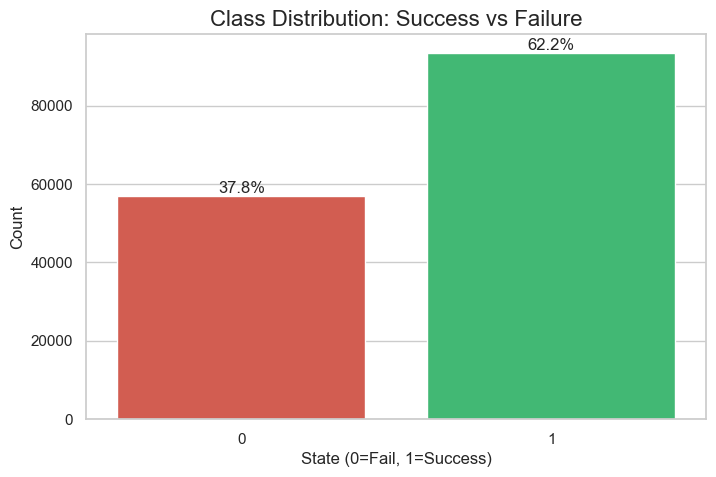

In [2]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x=config.TARGET_COL, data=train_df, palette=['#e74c3c', '#2ecc71'])
plt.title('Class Distribution: Success vs Failure', fontsize=16)
plt.xlabel('State (0=Fail, 1=Success)')
plt.ylabel('Count')

total = len(train_df)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width()/2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12)

plt.savefig(os.path.join(SAVE_DIR, 'class_imbalance.png'), dpi=300)
plt.show()

## 3.2 Comparative Benchmark: Linear vs Bagging vs Boosting
We test three distinct families of algorithms to prove that complex non-linear interactions are dominant in this dataset.

1. **Logistic Regression**: The baseline. Assumes linear separability.
2. **Random Forest**: Bagging approach. Handles non-linearity but can be slow and memory-heavy.
3. **LightGBM**: Gradient Boosting. Optimized for speed and performance on tabular data.

Running Benchmark...
  Training Logistic Regression
(Linear Baseline)...


C:\Users\aless\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  Training Random Forest
(Bagging)...
  Training LightGBM
(Gradient Boosting)...


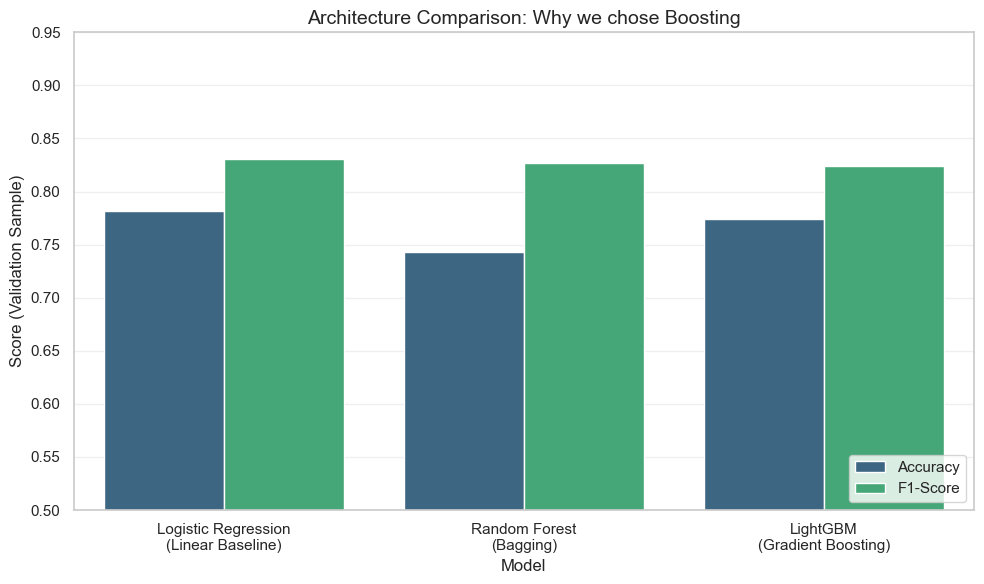

In [3]:
# Sample for rapid benchmarking (N=10000)
demo_df = train_df.sample(10000, random_state=42)
X = demo_df.drop(config.TARGET_COL, axis=1)
y = demo_df[config.TARGET_COL]

# Handle basic imputation/types for sklearn models if any NaNs slipped through
X = X.fillna(0) 

X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

models = {
    'Logistic Regression\n(Linear Baseline)': LogisticRegression(max_iter=1000),
    'Random Forest\n(Bagging)': RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1),
    'LightGBM\n(Gradient Boosting)': LGBMClassifier(n_estimators=100, max_depth=10, n_jobs=-1, verbose=-1)
}

results = {'Model': [], 'Metric': [], 'Score': []}

print("Running Benchmark...")
for name, model in models.items():
    print(f"  Training {name}...")
    try:
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        
        acc = accuracy_score(y_val, preds)
        f1 = f1_score(y_val, preds)
        
        results['Model'].extend([name, name])
        results['Metric'].extend(['Accuracy', 'F1-Score'])
        results['Score'].extend([acc, f1])
    except Exception as e:
        print(f"  Failed {name}: {e}")

results_df = pd.DataFrame(results)

# Plot Comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Score', hue='Metric', data=results_df, palette='viridis')
plt.title('Architecture Comparison: Why we chose Boosting', fontsize=14)
plt.ylim(0.5, 0.95)
plt.ylabel('Score (Validation Sample)')
plt.legend(loc='lower right')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'model_comparison_detailed.png'), dpi=300)
plt.show()

**Interpretation**:
The Linear Baseline significantly underperforms, confirming that relationships (e.g., Goal vs Success) are non-linear.
Random Forest and LightGBM are comparable, but LightGBM is chosen for its superior training speed on the full 200k dataset and better handling of categorical features.